## CAR ANALYSTIC


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('./data/car_prices.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [3]:
data.sample()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
315849,2011,Ford,Transit Connect,Cargo Van XLT,Minivan,automatic,nm0ls7dn3bt047690,ca,2.0,56609.0,white,gray,enterprise fm exchange/tra/lease,10950.0,11000.0,Tue Feb 17 2015 04:00:00 GMT-0800 (PST)


In [4]:
data.head(5)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [5]:
data.tail(5)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
558832,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
558833,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)
558836,2014,Ford,F-150,XLT,SuperCrew,automatic,1ftfw1et2eke87277,ca,34.0,15008.0,gray,gray,ford motor credit company llc pd,29600.0,26700.0,Thu May 28 2015 05:30:00 GMT-0700 (PDT)


In [6]:
data.shape

(558837, 16)

In [7]:
data.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


### Kiểm tra giá trị duplicate

In [8]:
data_1 = data.copy()

In [9]:
data_1.duplicated().sum()

np.int64(0)

### Kiểm tra giá trị missing

In [10]:
def missing_values(df):
        mis_val = df.isnull().sum()
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Số giá trị Missing', 1 : 'Tỷ lệ % missing'})
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        'Tỷ lệ % missing', ascending=False).round(4)
        print ("File dữ liệu bao gồm có: " + str(df.shape[1]) + " cột.\n"      
            "Có " + str(mis_val_table_ren_columns.shape[0]) +
              " cột chứa missing values.")
        return mis_val_table_ren_columns

#Check dữ liệu missing trong DataFrame: 
missing_values(data_1)

File dữ liệu bao gồm có: 16 cột.
Có 13 cột chứa missing values.


,Số giá trị Missing,Tỷ lệ % missing
transmission,65352,11.6943
body,13195,2.3612
condition,11820,2.1151
trim,10651,1.9059
model,10399,1.8608
make,10301,1.8433
color,749,0.1340
interior,749,0.1340
odometer,94,0.0168
mmr,38,0.0068


In [11]:
data_1['transmission'].value_counts(dropna=False)

transmission
automatic    475915
NaN           65352
manual        17544
sedan            15
Sedan            11
Name: count, dtype: int64

In [12]:
data_1['body'].unique()

array(['SUV', 'Sedan', 'Convertible', 'Coupe', 'Wagon', 'Hatchback',
       'Crew Cab', 'G Coupe', 'G Sedan', 'Elantra Coupe', 'Genesis Coupe',
       'Minivan', nan, 'Van', 'Double Cab', 'CrewMax Cab', 'Access Cab',
       'King Cab', 'SuperCrew', 'CTS Coupe', 'Extended Cab',
       'E-Series Van', 'SuperCab', 'Regular Cab', 'G Convertible', 'Koup',
       'Quad Cab', 'CTS-V Coupe', 'sedan', 'G37 Convertible', 'Club Cab',
       'Xtracab', 'Q60 Convertible', 'CTS Wagon', 'convertible',
       'G37 Coupe', 'Mega Cab', 'Cab Plus 4', 'Q60 Coupe', 'Cab Plus',
       'Beetle Convertible', 'TSX Sport Wagon', 'Promaster Cargo Van',
       'GranTurismo Convertible', 'CTS-V Wagon', 'Ram Van', 'minivan',
       'suv', 'Transit Van', 'Navitgation', 'van', 'regular-cab',
       'g sedan', 'g coupe', 'hatchback', 'king cab', 'supercrew',
       'g convertible', 'coupe', 'crew cab', 'wagon', 'double cab',
       'e-series van', 'regular cab', 'quad cab', 'g37 convertible',
       'supercab', 'exten

In [13]:
data_1['transmission'] = data_1['transmission'].fillna('unknown').apply(lambda x: x.lower().strip())
data_1['body'] = data_1['body'].fillna('other').apply(lambda x: x.lower().strip())
data_1['condition'] = data_1['condition'].fillna(data_1['condition'].median())

def clean_body(body):
    if 'coupe' in body or 'koup' in body:
        return 'coupe'
    if 'sedan' in body:
        return 'sedan'
    if 'wagon' in body:
        return 'wagon'
    if 'convertible' in body:
        return 'convertible'
    if 'cab' in body or 'supercrew' in body:
        return 'truck'
    if 'van' in body or 'minivan' in body:
        return 'van'
    if 'hatchback' in body:
        return 'hatchback'
    return 'other'
data_1['body'] = data_1['body'].apply(clean_body)


data_1['color'] = data_1['color'].fillna('unknown').apply(lambda x: x.lower().strip())
data_1['trim'] = data_1['trim'].fillna('unknown').apply(lambda x: x.lower().strip())
data_1['model'] = data_1['model'].fillna('unknown').apply(lambda x: x.lower().strip())
data_1['make'] = data_1['make'].fillna('unknown').apply(lambda x: x.lower().strip())
data_1 = data_1.dropna(subset=["interior", "odometer", "mmr", "sellingprice", "saledate"])
data_1 = data_1.drop(columns=["vin"])

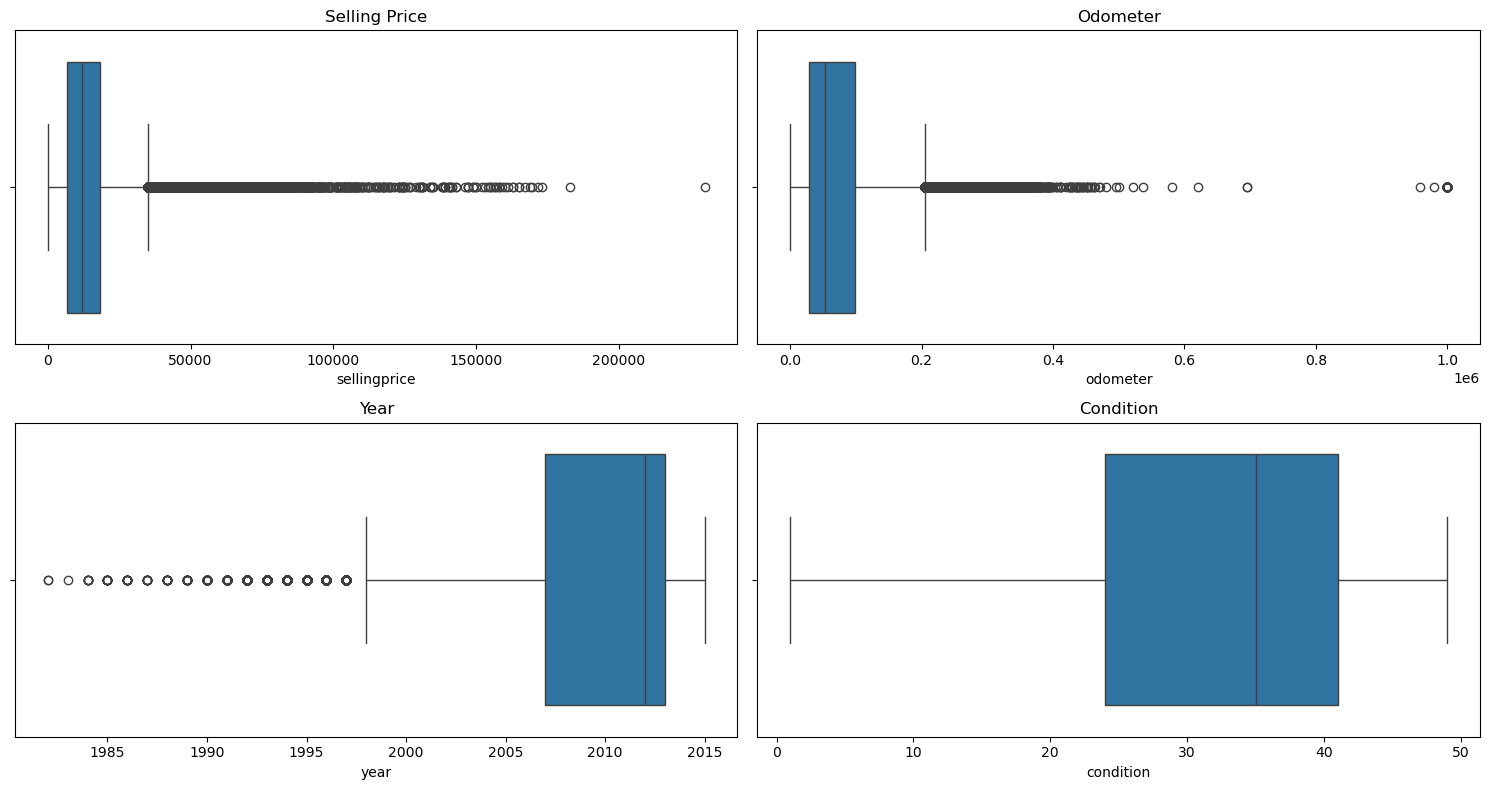

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

sns.boxplot(x=data_1["sellingprice"], ax=axes[0,0])
axes[0,0].set_title("Selling Price")

sns.boxplot(x=data_1["odometer"], ax=axes[0,1])
axes[0,1].set_title("Odometer")

sns.boxplot(x=data_1["year"], ax=axes[1,0])
axes[1,0].set_title("Year")

sns.boxplot(x=data_1["condition"], ax=axes[1,1])
axes[1,1].set_title("Condition")

plt.tight_layout()
plt.show()

In [15]:
# IQR
num_cols = ["sellingprice", "odometer", "year"]

def detect_outliers(df, cols):

    result = {}

    for col in cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[
            (df[col] < lower) |
            (df[col] > upper)
        ]

        result[col] = outliers

        print(f"{col}: {len(outliers)} outliers")

    return result

outliers = detect_outliers(data_1, num_cols)

sellingprice: 16204 outliers
odometer: 10340 outliers
year: 4008 outliers


In [16]:
data_filtered = data_1[
    (data_1['sellingprice'] > 500) & (data_1['sellingprice'] <= 200000) &
    (data_1['year'] >= 1990) & (data_1['year'] <= 2026)
]

In [17]:
data_1['odometer'] = data_1['odometer'].replace(999999, np.nan)
data_1['odometer'] = data_1['odometer'].fillna(data_1['odometer'].median())

In [ ]:
data_1.to_csv("cleaned_data.csv", index=False)